# [Task 0.0] : GPU Set up

Add GPU accelerator by clicking
Runtime>Change runtime type > Hardware accelerator

Change from None to GPU


Following code block should pass without triggering asserts if you did it rightly.

**Caution: Do not proceed further until this code block passes**




In [1]:
import torch
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

# Assuming that we are on a CUDA machine, this should print a CUDA device:

print(f"We are training on {device} for this experiment")

assert 'cuda' in repr(device), "GPU is not selected in hardware accelerator dropdown"

We are training on cuda:0 for this experiment


In [2]:
print(device)

cuda:0


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
!mkdir /content/drive/MyDrive/checkpoints/

#[Task 0.1] : Google drive setup
Create a folder '*checkpoints*' in your google drive and make `your_google_drive_path` variable to point the '*checkpoints*' folder.

Following code block should pass without triggering asserts if you did it rightly.

**Caution: Do not proceed further until this code block passes** *italicised text*

In [6]:
your_google_drive_path = "/content/drive/MyDrive/checkpoints/"
import os
assert os.path.isdir(your_google_drive_path), f"{your_google_drive_path} is not a valid location"


# Training a Classifier

This is it. You have seen how to define neural networks, compute loss and make
updates to the weights of the network.

Now you might be thinking,

## What about data?

Generally, when you have to deal with image, text, audio or video data,
you can use standard python packages that load data into a numpy array.
Then you can convert this array into a ``torch.*Tensor``.

-  For images, packages such as Pillow, OpenCV are useful
-  For audio, packages such as scipy and librosa
-  For text, either raw Python or Cython based loading, or NLTK and
   SpaCy are useful

Specifically for vision, we have created a package called
``torchvision``, that has data loaders for common datasets such as
ImageNet, CIFAR10, MNIST, etc. and data transformers for images, viz.,
``torchvision.datasets`` and ``torch.utils.data.DataLoader``.

This provides a huge convenience and avoids writing boilerplate code.

For this tutorial, we will use the CIFAR10 dataset.
It has the classes: ‘airplane’, ‘automobile’, ‘bird’, ‘cat’, ‘deer’,
‘dog’, ‘frog’, ‘horse’, ‘ship’, ‘truck’. The images in CIFAR-10 are of
size 3x32x32, i.e. 3-channel color images of 32x32 pixels in size.

.. figure:: /_static/img/cifar10.png
   :alt: cifar10

   cifar10


## Training an image classifier

We will do the following steps in order:

1. Load and normalize the CIFAR10 training and test datasets using
   ``torchvision``
2. Define a Convolutional Neural Network
3. Define a loss function
4. Train the network on the training data
5. Test the network on the test data

### 1. Load and normalize CIFAR10

Using ``torchvision``, it’s extremely easy to load CIFAR10.


In [7]:
%matplotlib inline
import torch
import torchvision
import torchvision.transforms as transforms

torch.manual_seed(41)

The output of torchvision datasets are PILImage images of range [0, 1].
We transform them to Tensors of normalized range [-1, 1].



<div class="alert alert-info"><h4>Note</h4><p>If running on Windows and you get a BrokenPipeError, try setting
    the num_worker of torch.utils.data.DataLoader() to 0.</p></div>



In [8]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5), (0.5))])#mean and SD

batch_size = 64

#Get dataset class object corresponding to train split
trainset = torchvision.datasets.MNIST(root='./data', train=True,
                                        download=True, transform=transform)

#Create data loader from train dataset object
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

#Get dataset class object corresponding to test split
testset = torchvision.datasets.MNIST(root='./data', train=False,
                                       download=True, transform=transform)

#Create data loader from test dataset object
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)

classes = ('zero', 'one', 'two', 'three',
           'four', 'five', 'six', 'seven', 'eight', 'nine') #tupple

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.38MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 127kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.22MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.5MB/s]


Let us show some of the training images, for fun.



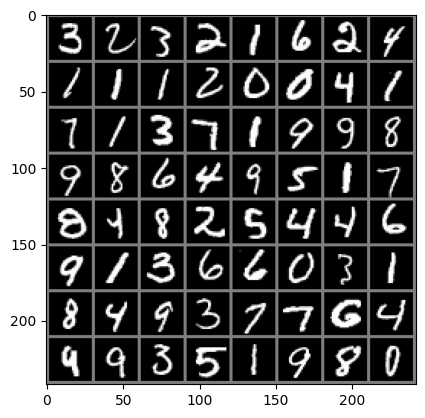

three two   three two   one   six   two   four  one   one   one   two   zero  zero  four  one   seven one   three seven one   nine  nine  eight nine  eight six   four  nine  five  one   seven eight four  eight two   five  four  four  six   nine  one   three six   six   zero  three one   eight four  nine  three seven seven six   four  four  nine  three five  one   nine  eight zero 


In [9]:
import matplotlib.pyplot as plt
import numpy as np

# functions to show an image


def imshow(img):
    img = img / 2 + 0.5     # unnormalize, range 0 to 1
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images

imshow(torchvision.utils.make_grid(images)) #flattening the image
# print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))#mapping the label j to class

### 2. [Task 1] Define a Convolutional Neural Network without residual connections
Copy the neural network from your lab and modify it to
take 3-channel images (instead of 1-channel images as it was defined), and output 10 classes in final layer of FC
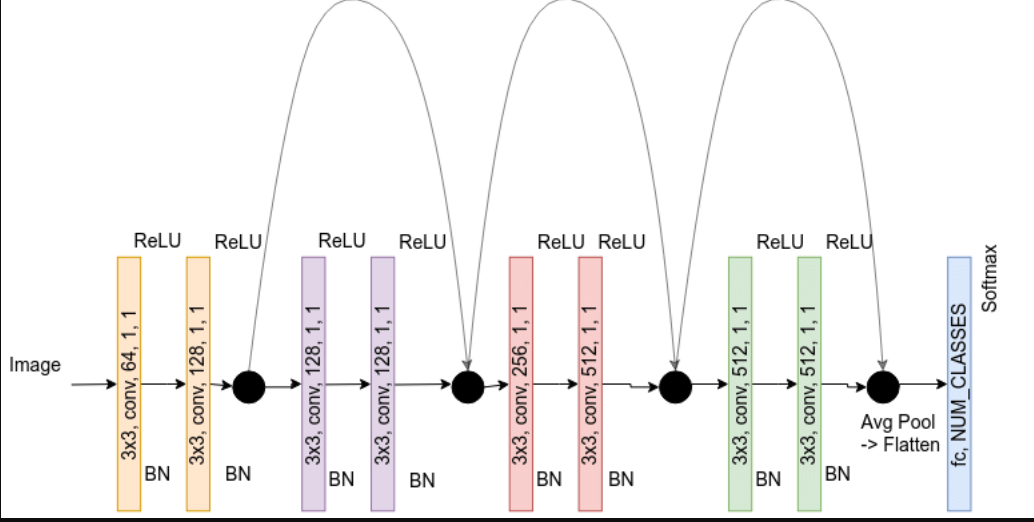



In [10]:

import torch.nn as nn
import torch.nn.functional as F

#Define your own 'resnet9 without residual connections' neural network class with name 'Net' here
#Note :
######## Thou shall not use the following commented out Net() definition in final evaluation
######## This is placed here for you to play with incase your model class definition doesn't work

class Net(nn.Module):
    def __init__(self):
        super().__init__()

        self.convblock1 = nn.Sequential(
            nn.Conv2d(1, 64, 3, padding=1, stride=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace = True),
            nn.Conv2d(64, 128, 3, padding=1, stride=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace = True),
        )

        self.convblock2 = nn.Sequential(
            nn.Conv2d(128, 128, 3, padding=1, stride=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace = True),
            nn.Conv2d(128, 128, 3, padding=1, stride=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace = True),
        )

        self.skipblock = nn.Sequential(
            nn.Conv2d(128, 512, 1, stride=2, padding=0, bias=False),
            nn.BatchNorm2d(512)
        )

        self.convblock3 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1, stride=2), # spatial dimension 14*14
            nn.BatchNorm2d(256),
            nn.ReLU(inplace = True),
            nn.Conv2d(256, 512, 3, padding=1, stride=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace = True),
        )

        self.convblock4 = nn.Sequential(
            nn.Conv2d(512, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace = True),
            nn.Conv2d(512, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace = True),
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, 10)

    def forward(self, x):

        x = self.convblock1(x)
        y = self.convblock2(x) + x
        z = self.convblock3(y) + self.skipblock(y)
        p = self.convblock4(z) + z

        p = self.pool(p) # Spatial dimension 7*7

        x = torch.flatten(p, 1)
        x = self.fc(x)
        return x


In [11]:
net = Net().to(device)

### 3. Define a Loss function and optimizer
Let's use a Classification Cross-Entropy loss and SGD with momentum.



In [12]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

## This is validator code, Read section 5 first if you don't understand this, and then comback to this code

In [13]:
  #validation and classwise accuracy
def validator_classwise(testloader=None,net=None, classes=None):
    # prepare to count predictions for each class
    correct_pred = {classname: 0 for classname in classes}
    total_pred = {classname: 0 for classname in classes}

    net.eval()

    # again no gradients needed
    with torch.no_grad():
        for data in testloader:
            images, labels = data
            images = images.to(device)
            labels = labels.to(device)
            outputs = net(images)
            _, predictions = torch.max(outputs, 1)
            # collect the correct predictions for each class
            for label, prediction in zip(labels, predictions):
                if label == prediction:
                    correct_pred[classes[label]] += 1
                total_pred[classes[label]] += 1

    total = sum(list(total_pred.values()))
    correct = sum(list(correct_pred.values()))
    # print accuracy for each class
    for classname, correct_count in correct_pred.items():
        accuracy = 100 * float(correct_count) / total_pred[classname]
        print(f'Accuracy for class: {classname:5s} is {accuracy:.1f} %')

    print(f'Accuracy of the network on the {len(testloader.dataset)} test images: {100 * correct // total} %')
    return correct/total

### 4. Train the network

This is when things start to get interesting.
We simply have to loop over our data iterator, and feed the inputs to the
network and optimize.



In [18]:
start_epoch=0
end_epoch=10

#If you are resuming your model, Uncomment following lines

checkpoint = torch.load(your_google_drive_path+'checkpoint.pth')
start_epoch = checkpoint['epoch']+1
net.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

In [19]:
# os.remove(your_google_drive_path+'best_model.pth')
# os.remove(your_google_drive_path+'checkpoint.pth')

In [20]:
best_accuracy = -1.0
log_interval = 200
for epoch in range(start_epoch,end_epoch):  # loop over the dataset multiple times



    net.train()
    print(f"************Epoch={epoch}************")
    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data

        inputs = inputs.to(device)
        labels = labels.to(device)

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward() #calculate the gradient and accumulate it
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if i % log_interval == log_interval-1:    # print every log_interval mini-batches
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / log_interval:.3f}')
            running_loss = 0.0

    current_accuracy = validator_classwise(testloader=testloader,net=net,classes=classes)
    if current_accuracy>best_accuracy:
        best_accuracy = current_accuracy

        torch.save(
            {'epoch':epoch,
             'model_state_dict': net.state_dict(),
             'optimizer_state_dict': optimizer.state_dict()
             },

             your_google_drive_path+'best_model.pth')

    #Save model as checkpoint, (here datatype dictionary)
    torch.save(
        {'epoch':epoch,
         'model_state_dict': net.state_dict(),
         'optimizer_state_dict': optimizer.state_dict()
         },
         your_google_drive_path+'checkpoint.pth')



print('Finished Training')

************Epoch=1************
[2,   200] loss: 0.131
[2,   400] loss: 0.112
[2,   600] loss: 0.107
[2,   800] loss: 0.087
Accuracy for class: zero  is 96.6 %
Accuracy for class: one   is 99.5 %
Accuracy for class: two   is 98.8 %
Accuracy for class: three is 99.7 %
Accuracy for class: four  is 97.6 %
Accuracy for class: five  is 98.4 %
Accuracy for class: six   is 96.7 %
Accuracy for class: seven is 97.3 %
Accuracy for class: eight is 95.4 %
Accuracy for class: nine  is 96.0 %
Accuracy of the network on the 10000 test images: 97 %
************Epoch=2************
[3,   200] loss: 0.077
[3,   400] loss: 0.075
[3,   600] loss: 0.071
[3,   800] loss: 0.064
Accuracy for class: zero  is 99.2 %
Accuracy for class: one   is 99.7 %
Accuracy for class: two   is 98.6 %
Accuracy for class: three is 96.8 %
Accuracy for class: four  is 98.4 %
Accuracy for class: five  is 99.3 %
Accuracy for class: six   is 97.4 %
Accuracy for class: seven is 98.9 %
Accuracy for class: eight is 85.2 %
Accuracy for 

### 5. Test the network on the test data

We have trained the network for `end_epoch` passes over the training dataset.
But we need to check if the network has learnt anything at all.

We will check this by predicting the class label that the neural network
outputs, and checking it against the ground-truth. If the prediction is
correct, we add the sample to the list of correct predictions.

Okay, first step. Let us display an image from the test set to get familiar.



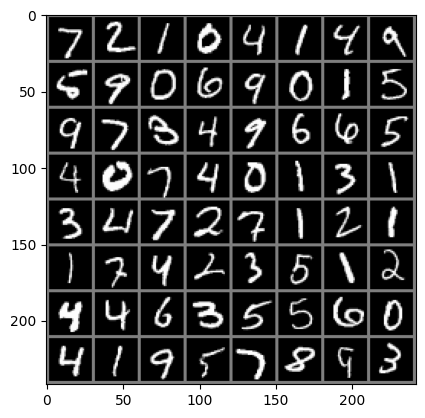

GroundTruth:  seven two   one   zero  four  one   four  nine  five  nine 


In [21]:
import matplotlib.pyplot as plt
import numpy as np

def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

dataiter = iter(testloader)
images, labels = next(dataiter)
# print images
imshow(torchvision.utils.make_grid(images))
print('GroundTruth: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(10)))

Load your best saved model and see what the neural network thinks these examples above are:

In [22]:
net_best = Net().to(device)
checkpoint = torch.load(your_google_drive_path+'best_model.pth')
# print(checkpoint['optimizer_state_dict'])
net_best.load_state_dict(checkpoint['model_state_dict'])


images = images.to(device)
labels = labels.to(device)

outputs = net_best(images)

The outputs are energies for the 10 classes.
The higher the energy for a class, the more the network
thinks that the image is of the particular class.
So, let's get the index of the highest energy:



In [23]:
_, predicted = torch.max(outputs, 1)
# print(_, predicted)

print('Predicted: ', ' '.join(f'{classes[predicted[j]]:5s}'
                              for j in range(len(predicted))))

Predicted:  seven two   one   zero  four  one   four  nine  five  nine  zero  six   nine  zero  one   five  nine  seven three four  nine  six   six   five  four  zero  seven four  zero  one   three one   three four  seven two   seven one   two   one   one   seven four  two   three five  one   two   four  four  six   three five  five  six   zero  four  one   nine  five  seven eight nine  three


# [Task 2] : Optional
Modify following function to return "total accuracy" which is caclculated from "class wise" accuracies and replace `validator()` function in training loop with `validator_classwise()` function.

## Classwise Validation accuracy MNIST

In [24]:
#Test your logic by uncommenting following line
_ = validator_classwise(testloader=testloader,net=net, classes=classes)

Accuracy for class: zero  is 99.7 %
Accuracy for class: one   is 99.7 %
Accuracy for class: two   is 98.8 %
Accuracy for class: three is 99.6 %
Accuracy for class: four  is 99.0 %
Accuracy for class: five  is 98.8 %
Accuracy for class: six   is 97.6 %
Accuracy for class: seven is 99.2 %
Accuracy for class: eight is 99.2 %
Accuracy for class: nine  is 98.9 %
Accuracy of the network on the 10000 test images: 99 %



# Part 2: Defining custom dataset class and Training Resnet-9 with telugu numbers dataset

In [25]:
# Custom dataloader
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import os
import cv2
import torchvision.transforms as transforms

from torchvision import datasets, transforms

# Creating a custom dataset class
class CustomImageDataset(torch.utils.data.Dataset):
    def __init__(self, root_dir, transform=None, classes=None):
      self.root_dir = root_dir
      self.transform = transform

      if classes:
        self.classes = classes
      else:
        self.classes = sorted(os.listdir(root_dir))

      self.class_to_idx = {cls_name: idx for (idx, cls_name) in enumerate(self.classes)}

      self.samples = []

      for cls_name in self.classes:
          cls_folder = os.path.join(root_dir, cls_name)
          for img_name in os.listdir(cls_folder):
              img_path = os.path.join(cls_folder, img_name)
              label = self.class_to_idx[cls_name]
              self.samples.append((img_path, label))

    # Defining the length of the dataset
    def __len__(self):
        return len(self.samples)

    # Defining the method to get an item from the dataset
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        if self.transform:
            image = self.transform(image)

        return image, label

In [29]:
import os

transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5), (0.5))])#mean and SD

batch_size = 64

# Define base path for the dataset
dataset_base_path = "/content/drive/MyDrive/Colab Notebooks/dataset"

# Create train and test directories if they don't exist
for folder in ["train", "test"]:
    path = os.path.join(dataset_base_path, folder)
    os.makedirs(path, exist_ok=True)

# Train set
trainset = CustomImageDataset(os.path.join(dataset_base_path, "train"), transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

# Test set
testset = CustomImageDataset(os.path.join(dataset_base_path, "test"), transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)

print(f"Trainset: {len(trainloader.dataset)}")
print(f"Testset: {len(testloader.dataset)}")

Trainset: 1150
Testset: 290


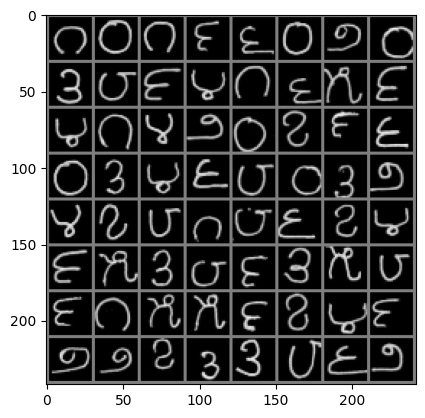

Digit1 Digit0 Digit1 Digit9 Digit6 Digit0 Digit2 Digit0 Digit3 Digit8 Digit9 Digit4 Digit1 Digit6 Digit5 Digit9 Digit4 Digit1 Digit4 Digit2 Digit0 Digit7 Digit9 Digit6 Digit0 Digit3 Digit4 Digit6 Digit8 Digit0 Digit3 Digit2 Digit4 Digit7 Digit8 Digit1 Digit8 Digit6 Digit7 Digit4 Digit9 Digit5 Digit3 Digit8 Digit9 Digit3 Digit5 Digit8 Digit9 Digit1 Digit5 Digit5 Digit9 Digit7 Digit4 Digit9 Digit2 Digit2 Digit7 Digit3 Digit3 Digit8 Digit6 Digit2


In [30]:
import matplotlib.pyplot as plt
import numpy as np

# functions to show an image


def imshow(img):
    img = img / 2 + 0.5     # unnormalize, range 0 to 1
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images

imshow(torchvision.utils.make_grid(images)) #flattening the image
# print labels
print(' '.join(f'{trainset.classes[labels[j]]:5s}' for j in range(batch_size)))#mapping the label j to class


# Training the Network


In [46]:
import torch.optim as optim

model = Net().to(device)
criterion = nn.CrossEntropyLoss()
optimizer2 = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
start_epoch=0
end_epoch=10


#checkpoint = torch.load(your_google_drive_path+'checkpoint_telugu_numbers.pth')
#start_epoch = checkpoint['epoch']+1
#model.load_state_dict(checkpoint['model_state_dict'])
#optimizer2.load_state_dict(checkpoint['optimizer_state_dict'])

In [47]:
best_accuracy = -1.0
log_interval = 5
for epoch in range(start_epoch,end_epoch):  # loop over the dataset multiple times

    model.train()
    print(f"************Epoch={epoch}************")
    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data

        inputs = inputs.to(device)
        labels = labels.to(device)

        # zero the parameter gradients
        optimizer2.zero_grad()

        # forward + backward + optimize
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward() #calculate the gradient and accumulate it
        optimizer2.step()

        # print statistics
        running_loss += loss.item()
        if i % log_interval == log_interval-1:    # print every log_interval mini-batches
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / log_interval:.3f}')
            running_loss = 0.0

    current_accuracy = validator_classwise(testloader=testloader,net=model,classes=trainset.classes)
    if current_accuracy>best_accuracy:
        best_accuracy = current_accuracy

        torch.save(
            {'epoch':epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer2.state_dict()
            },

            your_google_drive_path+'best_model_telugu_numbers.pth')

    #Save model as checkpoint, (here datatype dictionary)
    torch.save(
        {'epoch':epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer2.state_dict()
        },
        your_google_drive_path+'checkpoint_telugu_numbers.pth')

print('Finished Training')

************Epoch=0************
[1,     5] loss: 2.400
[1,    10] loss: 2.263
[1,    15] loss: 2.186
Accuracy for class: Digit0 is 0.0 %
Accuracy for class: Digit1 is 100.0 %
Accuracy for class: Digit2 is 0.0 %
Accuracy for class: Digit3 is 0.0 %
Accuracy for class: Digit4 is 0.0 %
Accuracy for class: Digit5 is 0.0 %
Accuracy for class: Digit6 is 0.0 %
Accuracy for class: Digit7 is 0.0 %
Accuracy for class: Digit8 is 0.0 %
Accuracy for class: Digit9 is 0.0 %
Accuracy of the network on the 290 test images: 10 %
************Epoch=1************
[2,     5] loss: 2.033
[2,    10] loss: 1.982
[2,    15] loss: 1.850
Accuracy for class: Digit0 is 0.0 %
Accuracy for class: Digit1 is 100.0 %
Accuracy for class: Digit2 is 0.0 %
Accuracy for class: Digit3 is 3.4 %
Accuracy for class: Digit4 is 0.0 %
Accuracy for class: Digit5 is 0.0 %
Accuracy for class: Digit6 is 0.0 %
Accuracy for class: Digit7 is 100.0 %
Accuracy for class: Digit8 is 0.0 %
Accuracy for class: Digit9 is 96.6 %
Accuracy of the ne

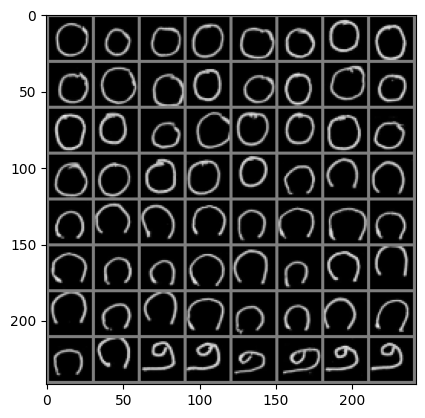

GroundTruth:  Digit0 Digit0 Digit0 Digit0 Digit0 Digit0 Digit0 Digit0 Digit0 Digit0


In [48]:
import matplotlib.pyplot as plt
import numpy as np

def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

dataiter = iter(testloader)
images, labels = next(dataiter)
# print images
imshow(torchvision.utils.make_grid(images))
print('GroundTruth: ', ' '.join(f'{testset.classes[labels[j]]:5s}' for j in range(10)))


# Validation accuracy for telugu numbers dataset


In [49]:
_ = validator_classwise(testloader=testloader,net=model, classes=trainset.classes)

Accuracy for class: Digit0 is 93.1 %
Accuracy for class: Digit1 is 100.0 %
Accuracy for class: Digit2 is 96.6 %
Accuracy for class: Digit3 is 100.0 %
Accuracy for class: Digit4 is 100.0 %
Accuracy for class: Digit5 is 96.6 %
Accuracy for class: Digit6 is 100.0 %
Accuracy for class: Digit7 is 100.0 %
Accuracy for class: Digit8 is 100.0 %
Accuracy for class: Digit9 is 89.7 %
Accuracy of the network on the 290 test images: 97 %



# Transfer Learning with Fine Tuning



## Training the network


In [50]:
import torch.optim as optim

model_tl = Net().to(device)


# Loading the best model parameters for MNIST dataset
checkpoint = torch.load(your_google_drive_path+'best_model.pth')
model_tl.load_state_dict(checkpoint['model_state_dict'])

# Reinitializing fc layer
in_features = model_tl.fc.in_features
model_tl.fc = (nn.Linear(in_features, len(trainset.classes))).to(device)

# Freezing layers other than MLP layer
for name, param in model_tl.named_parameters():
    if "fc" not in name:
        param.requires_grad = False

criterion = nn.CrossEntropyLoss()

optimizer_tl = optim.SGD(
    model_tl.parameters(filter(lambda p: p.requires_grad, model.parameters())),
    lr=0.001,
    momentum=0.9
)



In [54]:
start_epoch=0
end_epoch= 20

checkpoint = torch.load(your_google_drive_path+'checkpoint_telugu_numbers_tl.pth')
start_epoch = checkpoint['epoch']+1
model_tl.load_state_dict(checkpoint['model_state_dict'])
optimizer_tl.load_state_dict(checkpoint['optimizer_state_dict'])

In [55]:
best_accuracy = -1.0
log_interval = 5
for epoch in range(start_epoch,end_epoch):  # loop over the dataset multiple times

    model_tl.train()
    print(f"************Epoch={epoch}************")
    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data

        inputs = inputs.to(device)
        labels = labels.to(device)

        # zero the parameter gradients
        optimizer_tl.zero_grad()

        # forward + backward + optimize
        outputs = model_tl(inputs)
        loss = criterion(outputs, labels)
        loss.backward() #calculate the gradient and accumulate it
        optimizer_tl.step()

        # print statistics
        running_loss += loss.item()
        if i % log_interval == log_interval-1:    # print every log_interval mini-batches
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / log_interval:.3f}')
            running_loss = 0.0

    current_accuracy = validator_classwise(testloader=testloader,net=model_tl,classes=trainset.classes)
    if current_accuracy>best_accuracy:
        best_accuracy = current_accuracy

        torch.save(
            {'epoch':epoch,
            'model_state_dict': model_tl.state_dict(),
            'optimizer_state_dict': optimizer_tl.state_dict()
            },

            your_google_drive_path+'best_model_telugu_numbers_tl.pth')

    #Save model as checkpoint, (here datatype dictionary)
    torch.save(
        {'epoch':epoch,
        'model_state_dict': model_tl.state_dict(),
        'optimizer_state_dict': optimizer_tl.state_dict()
        },
        your_google_drive_path+'checkpoint_telugu_numbers_tl.pth')

print('Finished Training')

Finished Training



# Validation accuracy with Transfer learning


In [56]:
_ = validator_classwise(testloader=testloader, net= model_tl, classes=testloader.dataset.classes)

Accuracy for class: Digit0 is 100.0 %
Accuracy for class: Digit1 is 100.0 %
Accuracy for class: Digit2 is 100.0 %
Accuracy for class: Digit3 is 100.0 %
Accuracy for class: Digit4 is 100.0 %
Accuracy for class: Digit5 is 100.0 %
Accuracy for class: Digit6 is 82.8 %
Accuracy for class: Digit7 is 96.6 %
Accuracy for class: Digit8 is 100.0 %
Accuracy for class: Digit9 is 75.9 %
Accuracy of the network on the 290 test images: 95 %



# Telugu letters(first 10 vowels) recognition using RESNET-9


In [57]:
import kagglehub
import os

path = kagglehub.dataset_download("nithin1729s/telugu-letters")
path = path+ "/Final Dataset of Telugu Handwritten Chararcters/Test1/achulu"

100%|██████████| 337M/337M [00:18<00:00, 19.6MB/s]

Extracting files...


In [58]:
classes = ['a','aa','e','ee','u','uu','ru','ruu','i','ii']
print(classes)

['a', 'aa', 'e', 'ee', 'u', 'uu', 'ru', 'ruu', 'i', 'ii']


In [59]:
import torch
import torchvision
import torchvision.transforms as transforms

transform = transforms.Compose(
    [ transforms.ToPILImage(),
      transforms.Resize((50,50)),
      transforms.ToTensor(),
      transforms.Normalize((0.5), (0.5))])#mean and SD

batch_size = 64

dataset = CustomImageDataset(path, transform, classes)
train_size = int(0.9 * len(dataset))
test_size = len(dataset) - train_size

# Train Test split
trainset, testset = torch.utils.data.random_split(dataset, [train_size, test_size])


trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                          shuffle=False, num_workers=2)

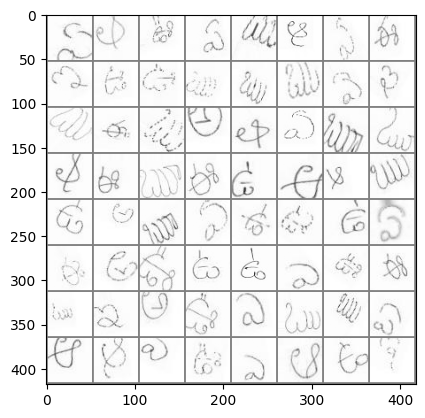

ii    aa    uu    ii    ru    aa    ii    ee    e     uu    uu    ru    ru    ru    ii    e     ruu   ee    ruu   a     aa    ii    ruu   ruu   aa    ee    ruu   ee    u     aa    aa    ru    u     a     ruu   ii    u     uu    u     ii    ee    a     uu    u     u     i     uu    ee    ru    e     a     uu    i     ru    ru    ii    aa    aa    i     uu    i     aa    u     e    


In [60]:
import matplotlib.pyplot as plt
import numpy as np

# functions to show an image

# Image dimension -> 50*50
def imshow(img):
    img = img / 2 + 0.5     # unnormalize, range 0 to 1
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)
# show images

imshow(torchvision.utils.make_grid(images)) #flattening the image
# print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))#mapping the label j to class



In [61]:
print(len(trainloader.dataset))
print(len(testloader.dataset))

5525
614



# Training Resnet on Telugu alphabets


In [62]:
import torch.optim as optim
alpha = Net().to(device)


criterion = nn.CrossEntropyLoss()
optimizer3 = optim.SGD(alpha.parameters(), lr=0.001, momentum=0.9)

In [70]:
start_epoch=0
end_epoch= 23

#If you are resuming your model, Uncomment following lines

checkpoint = torch.load(your_google_drive_path+'checkpoint_custom.pth')
start_epoch = checkpoint['epoch']+1
alpha.load_state_dict(checkpoint['model_state_dict'])
optimizer3.load_state_dict(checkpoint['optimizer_state_dict'])

In [71]:
best_accuracy = -1.0
log_interval = 50
for epoch in range(start_epoch,end_epoch):  # loop over the dataset multiple times

    alpha.train()
    print(f"************Epoch={epoch}************")
    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # get the inputs; data is a list of [inputs, labels]
        [inputs, labels] = data

        inputs = inputs.to(device)
        labels = labels.to(device)

        # zero the parameter gradients
        optimizer3.zero_grad()

        # forward + backward + optimize
        outputs = alpha(inputs)
        loss = criterion(outputs, labels)
        loss.backward() #calculate the gradient and accumulate it
        optimizer3.step()

        # print statistics
        running_loss += loss.item()
        if i % log_interval == log_interval-1:    # print every log_interval mini-batches
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / log_interval:.3f}')
            running_loss = 0.0

    current_accuracy = validator_classwise(testloader=testloader,net=alpha,classes=dataset.classes)
    if current_accuracy>best_accuracy:
        best_accuracy = current_accuracy

        torch.save(
            {'epoch':epoch,
             'model_state_dict': alpha.state_dict(),
             'optimizer_state_dict': optimizer3.state_dict()
             },

             your_google_drive_path+'best_model_custom.pth')

    #Save model as checkpoint, (here datatype dictionary)
    torch.save(
        {'epoch':epoch,
         'model_state_dict': alpha.state_dict(),
         'optimizer_state_dict': optimizer3.state_dict()
         },
         your_google_drive_path+'checkpoint_custom.pth')



print('Finished Training')

Finished Training



# Best Validation Accuracy


In [72]:
alpha_best = Net().to(device)
best_accuracy = torch.load(your_google_drive_path+'best_model_custom.pth')
alpha_best.load_state_dict(best_accuracy['model_state_dict'])

_ = validator_classwise(testloader, alpha_best, classes)

Accuracy for class: a     is 75.0 %
Accuracy for class: aa    is 92.2 %
Accuracy for class: e     is 100.0 %
Accuracy for class: ee    is 89.9 %
Accuracy for class: u     is 100.0 %
Accuracy for class: uu    is 92.4 %
Accuracy for class: ru    is 52.4 %
Accuracy for class: ruu   is 78.6 %
Accuracy for class: i     is 86.8 %
Accuracy for class: ii    is 98.4 %
Accuracy of the network on the 614 test images: 87 %
